In [1]:
import pandas as pd
import requests
import io

# 1. Direct IEM configuration for Boston Logan (BOS)
# Added 'p01i' to request 1-hour liquid precipitation accumulation in inches
# Added 'dwpf' for Dew Point Temperature in Fahrenheit, which can be used to calculate wet bulb temperature.
# Added 'sknt' for Wind Speed in knots.
IEM_URL = (
    "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?" # Corrected base URL
    "station=BOS&data=tmpf&data=relh&data=p01i&data=dwpf&data=sknt&" # Added p01i, dwpf, and sknt
    "year1=2024&month1=1&day1=1&"
    "year2=2025&month2=1&day2=1&"
    "tz=Etc%2FUTC&format=comma&latlon=no&missing=M"
)
YEAR = "2024"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

print("📡 Connecting to Iowa Environmental Mesonet (IEM)...")
print(f"⏳ Extracting {YEAR} hourly temperature, humidity, precipitation, dew point, and wind speed data...")

try:
    response = requests.get(IEM_URL, headers=headers)

    if response.status_code == 200:
        # Read payload, skipping comment rows marked with '#'
        df = pd.read_csv(
            io.StringIO(response.text),
            comment='#',
            na_values=['M', ' M', 'M ', '  M']
        )

        df.columns = df.columns.str.strip()

        if not df.empty and 'valid' in df.columns:
            # 2. Format dates and rename columns
            df['valid'] = pd.to_datetime(df['valid'])
            df = df.rename(columns={
                'valid': 'Timestamp_UTC',
                'tmpf': 'Air_Temp_F',
                'relh': 'Relative_Humidity_Pct',
                'p01i': 'Precipitation_Inches',
                'dwpf': 'Dew_Point_Temp_F', # Added dew point rename
                'sknt': 'Wind_Speed_Knots' # Added wind speed rename
            })

            # 3. Clean numeric fields and handle missing precipitation
            df['Air_Temp_F'] = pd.to_numeric(df['Air_Temp_F'], errors='coerce')
            df['Relative_Humidity_Pct'] = pd.to_numeric(df['Relative_Humidity_Pct'], errors='coerce')
            df['Dew_Point_Temp_F'] = pd.to_numeric(df['Dew_Point_Temp_F'], errors='coerce') # Added dew point to numeric conversion
            df['Wind_Speed_Knots'] = pd.to_numeric(df['Wind_Speed_Knots'], errors='coerce') # Added wind speed to numeric conversion

            # Weather stations record 0.00 for no rain, but missing data ('M') can also mean zero rain.
            # We fill missing precipitation values with 0.0 to prevent gaps in cumulative analysis.
            df['Precipitation_Inches'] = pd.to_numeric(df['Precipitation_Inches'], errors='coerce').fillna(0.0)

            # Filter layout to keep complete records
            clean_df = df[[
                'Timestamp_UTC',
                'Air_Temp_F',
                'Relative_Humidity_Pct',
                'Precipitation_Inches',
                'Dew_Point_Temp_F',
                'Wind_Speed_Knots'
            ]].dropna(subset=['Air_Temp_F']) # Dropping NaNs only based on Air_Temp_F

            # 5. Save complete data matrix to CSV
            output_filename = f"Boston_hourly_weather_with_precip_dewpoint_wind_{YEAR}.csv" # Updated filename
            clean_df.to_csv(output_filename, index=False)

            print(f"\n🎉 Success! The updated {YEAR} dataset has been generated.")
            print(f"💾 File saved to disk: '{output_filename}'")
            print(f"Total entries pulled: {len(clean_df)} records")
            print("\nPreview of your weather data grid:")
            print(clean_df.head(5).to_string(index=False))
            print(clean_df.tail(5).to_string(index=False))
        else:
            print("❌ Server returned data, but headers were invalid or empty.")
            print(f"Raw Snippet:\n{response.text[:300]}") # Add raw snippet for debugging
    else:
        print(f"❌ Connection failed with Status Code: {response.status_code}")

except Exception as e:
    print(f"❌ Local processing error: {e}")

📡 Connecting to Iowa Environmental Mesonet (IEM)...
⏳ Extracting 2024 hourly temperature, humidity, precipitation, dew point, and wind speed data...

🎉 Success! The updated 2024 dataset has been generated.
💾 File saved to disk: 'Boston_hourly_weather_with_precip_dewpoint_wind_2024.csv'
Total entries pulled: 10514 records

Preview of your weather data grid:
      Timestamp_UTC  Air_Temp_F  Relative_Humidity_Pct  Precipitation_Inches  Dew_Point_Temp_F  Wind_Speed_Knots
2024-01-01 00:00:00        35.0                  61.23                   0.0              23.0               9.0
2024-01-01 00:54:00        34.0                  63.72                   0.0              23.0               9.0
2024-01-01 01:54:00        33.0                  63.59                   0.0              22.0               7.0
2024-01-01 02:54:00        33.0                  66.32                   0.0              23.0               7.0
2024-01-01 03:54:00        33.0                  66.32                   0.0

In [2]:
import pandas as pd

# Load the previously saved hourly weather data, now including precipitation, dew point and wind speed
file_path = f"Boston_hourly_weather_with_precip_dewpoint_wind_{YEAR}.csv"
df_hourly = pd.read_csv(file_path)

# Ensure 'Timestamp_UTC' is a datetime object, then localize to UTC and set it as the index
df_hourly['Timestamp_UTC'] = pd.to_datetime(df_hourly['Timestamp_UTC'])
df_hourly = df_hourly.set_index('Timestamp_UTC').tz_localize('UTC')

# Resample to strict hourly frequency, taking the mean for any multiple entries within an hour
# 'h' stands for hourly frequency. .mean() aggregates data for each hour.
df_resampled = df_hourly.resample('h').mean()

# Generate a complete hourly time series for the entire year 2024
# This ensures we capture all possible hours, even if they were missing from the original data
start_date = pd.Timestamp(f'{YEAR}-01-01 00:00:00', tz='UTC')
end_date = pd.Timestamp(f'{YEAR}-12-31 23:00:00', tz='UTC') # End at 23:00 for full hours
full_hourly_index = pd.date_range(start=start_date, end=end_date, freq='h')

# Reindex the resampled DataFrame to the full hourly index
# This will introduce NaN values for any hours that were completely missing
df_full_hourly = df_resampled.reindex(full_hourly_index)

# Identify missing hours (where ALL relevant columns are NaN) BEFORE imputation
# This considers all columns that could potentially have NaNs after resampling
missing_hours_before_imputation = df_full_hourly[df_full_hourly.isnull().all(axis=1)].index

print(f"Found {len(missing_hours_before_imputation)} missing hours in the dataset BEFORE imputation:")
for hour in missing_hours_before_imputation:
    print(f"  {hour.strftime('%Y-%m-%d %H:%M')}")

# Impute missing hours: first, linear interpolation for internal gaps, then ffill/bfill for edges
df_imputed = df_full_hourly.interpolate(method='linear')
df_imputed = df_imputed.ffill() # Fill remaining NaNs by propagating the last valid observation forward
df_imputed = df_imputed.bfill() # Fill remaining NaNs by propagating the next valid observation backward

print("\nAggregation and imputation complete.")
print(f"Total hours in the aggregated dataset: {len(df_imputed)}")
print("First 5 rows of the processed hourly data (with imputation):")
display(df_imputed.head(5))
print("Last 5 rows of the processed hourly data (with imputation):")
display(df_imputed.tail(5))

# Check if any NaNs remain after imputation
if df_imputed.isnull().sum().sum() == 0:
    print("All missing values have been successfully imputed.")
else:
    print("WARNING: Some missing values still remain after imputation. Please review the data.")

output_filename_processed = f"Boston_hourly_weather_{YEAR}_processed_with_precip_wind.csv"
df_imputed.to_csv(output_filename_processed, index=True) # index=True to save the Timestamp_UTC index
print(f"Processed data saved to '{output_filename_processed}'")

# Identify hours that were originally missing (all columns NaN) in df_full_hourly
# Filter df_imputed to only include the rows corresponding to the originally missing hours
# And check which of these now have non-null values (meaning they were imputed)
imputed_hours_df = df_imputed.loc[missing_hours_before_imputation] # Use the index identified earlier

# An imputed hour is one that was in missing_hours_before_imputation AND is now no longer all NaN
actually_imputed_timestamps = imputed_hours_df[imputed_hours_df.notnull().any(axis=1)].index

print("\nIdentifying imputed hours...")
if len(actually_imputed_timestamps) > 0:
    print(f"\nSuccessfully imputed {len(actually_imputed_timestamps)} specific hours:")
    for hour in actually_imputed_timestamps:
        print(f"  {hour.strftime('%Y-%m-%d %H:%M')}")
else:
    print("\nNo specific hours were identified as being imputed from a completely missing state.")

Found 8 missing hours in the dataset BEFORE imputation:
  2024-03-23 13:00
  2024-05-08 13:00
  2024-08-20 00:00
  2024-10-31 04:00
  2024-11-23 13:00
  2024-12-23 18:00
  2024-12-24 20:00
  2024-12-29 13:00

Aggregation and imputation complete.
Total hours in the aggregated dataset: 8784
First 5 rows of the processed hourly data (with imputation):


,Air_Temp_F,Relative_Humidity_Pct,Precipitation_Inches,Dew_Point_Temp_F,Wind_Speed_Knots
2024-01-01 00:00:00+00:00,34.5,62.475,0.0,23.0,9.0
2024-01-01 01:00:00+00:00,33.0,63.590,0.0,22.0,7.0
2024-01-01 02:00:00+00:00,33.0,66.320,0.0,23.0,7.0
2024-01-01 03:00:00+00:00,33.0,66.320,0.0,23.0,5.0
2024-01-01 04:00:00+00:00,33.0,66.320,0.0,23.0,3.0


Last 5 rows of the processed hourly data (with imputation):


,Air_Temp_F,Relative_Humidity_Pct,Precipitation_Inches,Dew_Point_Temp_F,Wind_Speed_Knots
2024-12-31 19:00:00+00:00,49.0,58.30,0.0,35.0,5.0
2024-12-31 20:00:00+00:00,44.0,67.66,0.0,34.0,9.0
2024-12-31 21:00:00+00:00,42.0,79.11,0.0,36.0,4.0
2024-12-31 22:00:00+00:00,41.0,82.22,0.0,36.0,4.0
2024-12-31 23:00:00+00:00,43.0,73.16,0.0,35.0,3.0


All missing values have been successfully imputed.
Processed data saved to 'Boston_hourly_weather_2024_processed_with_precip_wind.csv'

Identifying imputed hours...

Successfully imputed 8 specific hours:
  2024-03-23 13:00
  2024-05-08 13:00
  2024-08-20 00:00
  2024-10-31 04:00
  2024-11-23 13:00
  2024-12-23 18:00
  2024-12-24 20:00
  2024-12-29 13:00


In [3]:
df_imputed.describe()

,Air_Temp_F,Relative_Humidity_Pct,Precipitation_Inches,Dew_Point_Temp_F,Wind_Speed_Knots
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,53.463170,68.363066,0.003978,42.192338,9.230870
std,16.605489,19.518601,0.023235,17.739124,4.441346
min,10.000000,12.890000,0.000000,-5.000000,0.000000
25%,40.000000,53.770000,0.000000,30.000000,6.000000
50%,53.000000,69.470000,0.000000,43.000000,9.000000
75%,67.000000,84.592500,0.000000,56.000000,12.000000
max,98.000000,100.000000,0.885000,77.000000,33.333333


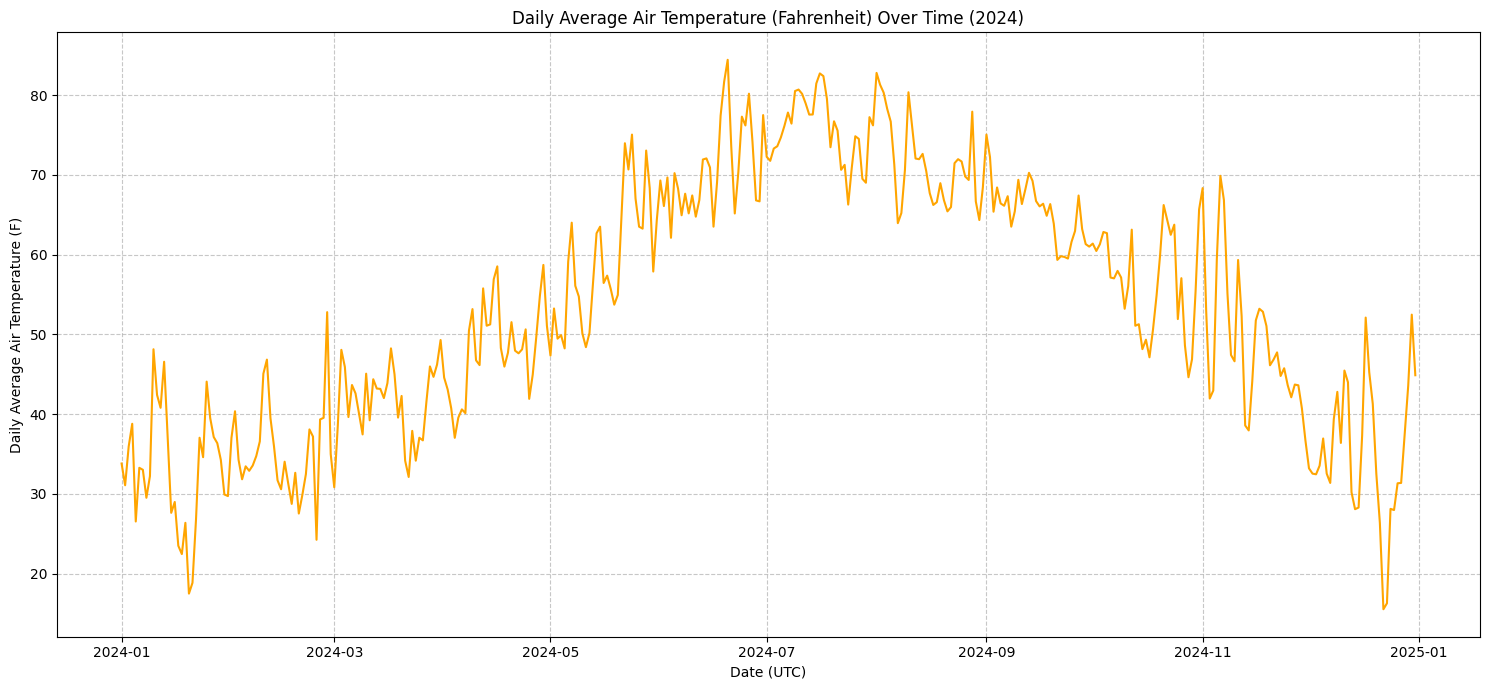

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate the hourly imputed temperature data to daily averages
daily_avg_temp_df = df_imputed['Air_Temp_F'].resample('D').mean().reset_index()

daily_avg_temp_df = daily_avg_temp_df.rename(columns={'index': 'Date', 'Air_Temp_F': 'Daily_Avg_Air_Temp_F'})

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Daily_Avg_Air_Temp_F', data=daily_avg_temp_df, color='orange')
plt.title(f'Daily Average Air Temperature (Fahrenheit) Over Time ({YEAR})')
plt.xlabel('Date (UTC)')
plt.ylabel('Daily Average Air Temperature (F)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'daily_avg_temp_{YEAR}.pdf')
plt.savefig(f'daily_avg_temp_{YEAR}.eps')
plt.show()

In [5]:
import os
import io
import zipfile
import requests
import pandas as pd

# 1. Configuration
YEAR = "2024"
BASE_URL = "https://s3.amazonaws.com/hubway-data"
OUTPUT_FILE = f"bluebikes_combined_{YEAR}.csv"

print(f"🚴 Starting Bluebikes {YEAR} automated download and data compilation...")

# Keep track of whether we are writing the very first file to handle header row logic
is_first_file = True

# 2. Iterate through all 12 months of the year
for month in range(1, 13):
    # Format month into a 2-digit string padding (e.g., '01', '02', ..., '12')
    month_str = f"{month:02d}"
    filename = f"{YEAR}{month_str}-bluebikes-tripdata.zip"
    download_url = f"{BASE_URL}/{filename}"

    print(f"\n⏳ Processing Month {month_str}/12...")
    print(f"🔗 Requesting: {download_url}")

    try:
        # 3. Stream zip file into memory to avoid cluttering local disk folders
        response = requests.get(download_url, stream=True)

        if response.status_code == 200:
            # Wrap bytes stream into an extractable object
            zip_data = zipfile.ZipFile(io.BytesIO(response.content))

            # Find the inner CSV file name inside the archive
            csv_filenames = [f for f in zip_data.namelist() if f.endswith('.csv') and not f.startswith('__')]

            if not csv_filenames:
                print(f"⚠️ No valid CSV file found inside {filename}. Skipping.")
                continue

            inner_csv_name = csv_filenames[0]
            print(f"📦 Found contents: '{inner_csv_name}'. Parsing into data matrix...")

            # 4. Stream and process the CSV directly into pandas chunks
            # chunksize limits RAM usage by loading rows in batches
            with zip_data.open(inner_csv_name) as csv_file:
                chunk_container = pd.read_csv(csv_file, chunksize=100000, low_memory=False)

                for chunk in chunk_container:
                    # Clear whitespace bugs out of table header templates
                    chunk.columns = chunk.columns.str.strip()

                    # 5. Incremental Append Strategy
                    if is_first_file:
                        # Write data row + column headers for the first data chunk
                        chunk.to_csv(OUTPUT_FILE, mode='w', index=False)
                        is_first_file = False
                    else:
                        # Append rows directly to bottom without repeating headers
                        chunk.to_csv(OUTPUT_FILE, mode='a', index=False, header=False)

            print(f"✅ Successfully compiled month {month_str}.")

        elif response.status_code == 404:
            print(f"❌ File not found (404). Month {month_str} might not be uploaded yet.")
        else:
            print(f"⚠️ Server returned response status: {response.status_code}")

    except Exception as e:
        print(f"💥 Failed to process month {month_str} due to error: {e}")

# 6. Summary Validation
if os.path.exists(OUTPUT_FILE):
    file_size_gb = os.path.getsize(OUTPUT_FILE) / (1024 ** 3)
    print("\n" + "="*50)
    print(f"🎉 Success! Compilation completed.")
    print(f"💾 Combined output file: '{OUTPUT_FILE}'")
    print(f"📦 Total Final File Size: {file_size_gb:.2f} GB")
    print("="*50)
else:
    print("\n❌ Script completed, but no merged output file was written.")


🚴 Starting Bluebikes 2024 automated download and data compilation...

⏳ Processing Month 01/12...
🔗 Requesting: https://s3.amazonaws.com/hubway-data/202401-bluebikes-tripdata.zip
📦 Found contents: '202401-bluebikes-tripdata.csv'. Parsing into data matrix...
✅ Successfully compiled month 01.

⏳ Processing Month 02/12...
🔗 Requesting: https://s3.amazonaws.com/hubway-data/202402-bluebikes-tripdata.zip
📦 Found contents: '202402-bluebikes-tripdata.csv'. Parsing into data matrix...
✅ Successfully compiled month 02.

⏳ Processing Month 03/12...
🔗 Requesting: https://s3.amazonaws.com/hubway-data/202403-bluebikes-tripdata.zip
📦 Found contents: '202403-bluebikes-tripdata.csv'. Parsing into data matrix...
✅ Successfully compiled month 03.

⏳ Processing Month 04/12...
🔗 Requesting: https://s3.amazonaws.com/hubway-data/202404-bluebikes-tripdata.zip
📦 Found contents: '202404-bluebikes-tripdata.csv'. Parsing into data matrix...
✅ Successfully compiled month 04.

⏳ Processing Month 05/12...
🔗 Requesti

In [6]:
import pandas as pd
df = pd.read_csv(f'bluebikes_combined_{YEAR}.csv')
df.head(10)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,D2F4A4783B230A84,electric_bike,2024-01-31 12:16:49,2024-01-31 12:21:02,Ames St at Main St,M32037,Central Square at Mass Ave / Essex St,M32011,42.362357,-71.088163,42.365070,-71.103100,member
1,D305CEFFD4558633,classic_bike,2024-01-12 08:14:16,2024-01-12 08:19:48,Ames St at Main St,M32037,Central Square at Mass Ave / Essex St,M32011,42.362500,-71.088220,42.365070,-71.103100,member
2,02009BB4EBA0D1F6,electric_bike,2024-01-29 15:00:05,2024-01-29 15:05:47,One Memorial Drive,M32053,Kennedy-Longfellow School 158 Spring St,M32065,42.361697,-71.080273,42.369553,-71.085790,member
3,04C230C1C39071F7,classic_bike,2024-01-09 16:33:40,2024-01-09 17:00:41,Ames St at Main St,M32037,Brookline Town Hall,K32005,42.362500,-71.088220,42.333765,-71.120464,member
4,CEAFE67E28B43852,classic_bike,2024-01-23 10:19:21,2024-01-23 10:31:39,Mass Ave T Station,C32063,Chinatown T Stop,D32019,42.341356,-71.083370,42.352409,-71.062679,member
5,07C37921B6834977,classic_bike,2024-01-26 12:35:20,2024-01-26 12:54:06,St. Alphonsus St at Tremont St,B32063,Stuart St at Charles St,D32011,42.333293,-71.101246,42.351146,-71.066289,member
6,F93AF0484FBA82B2,classic_bike,2024-01-23 12:50:25,2024-01-23 12:55:28,Ames St at Main St,M32037,Kennedy-Longfellow School 158 Spring St,M32065,42.362500,-71.088220,42.369553,-71.085790,member
7,2AC091C3370D3F31,classic_bike,2024-01-25 12:33:47,2024-01-25 12:40:51,Ames St at Main St,M32037,Central Square at Mass Ave / Essex St,M32011,42.362500,-71.088220,42.365070,-71.103100,member
8,D4EB63EDC18B910E,classic_bike,2024-01-24 16:26:29,2024-01-24 16:31:55,Ames St at Main St,M32037,Central Square at Mass Ave / Essex St,M32011,42.362500,-71.088220,42.365070,-71.103100,member
9,BE62062872481B25,classic_bike,2024-01-31 17:17:01,2024-01-31 17:21:44,Ames St at Main St,M32037,Kennedy-Longfellow School 158 Spring St,M32065,42.362500,-71.088220,42.369553,-71.085790,member


In [7]:
df.describe()

,start_lat,start_lng,end_lat,end_lng
count,4.751790e+06,4.751790e+06,4.748283e+06,4.748283e+06
mean,4.235850e+01,-7.108961e+01,4.235844e+01,-7.108948e+01
std,2.063945e-02,2.886854e-02,2.071784e-02,2.896790e-02
min,4.213793e+01,-7.127404e+01,4.184000e+01,-7.141000e+01
25%,4.234776e+01,-7.110707e+01,4.234776e+01,-7.110707e+01
50%,4.235815e+01,-7.109018e+01,4.235810e+01,-7.108995e+01
75%,4.236861e+01,-7.107036e+01,4.236861e+01,-7.106996e+01
max,4.253478e+01,-7.077670e+01,4.255000e+01,-7.087021e+01


In [8]:
import pandas as pd

# Ensure 'started_at' is a datetime object
df['started_at'] = pd.to_datetime(df['started_at'], format='mixed')

# Extract relevant time components
df['hour'] = df['started_at'].dt.hour
df['date'] = df['started_at'].dt.date
df['month'] = df['started_at'].dt.month
df['weekday'] = df['started_at'].dt.dayofweek + 1 # Get day of week as integer (Monday=0, Sunday=6), then add 1 to make Monday=1, Sunday=7

# Group by hour, date, month, and weekday and count the number of rentals
# Each row in the original df represents one rental, so a simple count will give total rentals.
hourly_rentals_df = df.groupby(['date', 'month', 'weekday', 'hour']).size().reset_index(name='rental')

# Sort the DataFrame for better readability
hourly_rentals_df = hourly_rentals_df.sort_values(by=['date', 'hour'])

# Display the first few rows of the new DataFrame
print("Preview of the hourly rentals DataFrame:")
display(hourly_rentals_df.head())

# Save the resulting DataFrame to a CSV file
output_filename = f"hourly_bluebikes_rentals_{YEAR}.csv"
hourly_rentals_df.to_csv(output_filename, index=False)

print(f"\nAggregated hourly rentals data saved to '{output_filename}'")
hourly_rentals_df.describe()

Preview of the hourly rentals DataFrame:


,date,month,weekday,hour,rental
0,2024-01-01,1,1,0,185
1,2024-01-01,1,1,1,208
2,2024-01-01,1,1,2,92
3,2024-01-01,1,1,3,32
4,2024-01-01,1,1,4,6



Aggregated hourly rentals data saved to 'hourly_bluebikes_rentals_2024.csv'


,month,weekday,hour,rental
count,8780.000000,8780.000000,8780.000000,8780.000000
mean,6.515945,3.985763,11.503872,541.206150
std,3.450507,2.003392,6.921762,502.065825
min,1.000000,1.000000,0.000000,1.000000
25%,4.000000,2.000000,6.000000,114.000000
50%,7.000000,4.000000,12.000000,415.000000
75%,10.000000,6.000000,18.000000,835.250000
max,12.000000,7.000000,23.000000,2731.000000


In [9]:
# 1. Create a complete hourly timestamp range for the entire year 2024
# Assuming YEAR is defined from previous cells (e.g., YEAR = '2024')
start_date = pd.Timestamp(f'{YEAR}-01-01 00:00:00', tz='UTC')
end_date = pd.Timestamp(f'{YEAR}-12-31 23:00:00', tz='UTC')
full_hourly_index = pd.date_range(start=start_date, end=end_date, freq='h')

# 2. Reconstruct a datetime index for the existing hourly_rentals_df for merging
hourly_rentals_df_indexed = hourly_rentals_df.copy()
hourly_rentals_df_indexed['datetime'] = pd.to_datetime(
    hourly_rentals_df_indexed['date'].astype(str) + ' ' +
    hourly_rentals_df_indexed['hour'].astype(str) + ':00:00'
)
hourly_rentals_df_indexed = hourly_rentals_df_indexed.set_index('datetime').tz_localize('UTC')

# 3. Reindex the existing hourly_rentals_df to the full hourly index
# This will introduce NaN values for hours that were not present in the original DataFrame.
hourly_rentals_df_complete = hourly_rentals_df_indexed.reindex(full_hourly_index)

# 4. Fill NaN values in the 'rental' column with 0 for the newly introduced missing hours
hourly_rentals_df_complete['rental'] = hourly_rentals_df_complete['rental'].fillna(0)

# 5. Populate the 'date', 'month', 'weekday', 'hour' columns for the newly added rows
# These columns would be NaN for the missing hours before this step.
hourly_rentals_df_complete['date'] = hourly_rentals_df_complete.index.date
hourly_rentals_df_complete['month'] = hourly_rentals_df_complete.index.month
hourly_rentals_df_complete['weekday'] = hourly_rentals_df_complete.index.dayofweek + 1 # Monday=1, Sunday=7
hourly_rentals_df_complete['hour'] = hourly_rentals_df_complete.index.hour

# 6. Identify the specific hours that were originally missing
missing_hours = full_hourly_index.difference(hourly_rentals_df_indexed.index)

print(f"Found {len(missing_hours)} missing hours that have been added and set to 0 rentals.")
if len(missing_hours) > 0:
    print("Missing hours:")
    for hour in missing_hours:
        print(f"  {hour.strftime('%Y-%m-%d %H:%M')}")

print(f"Total hours in hourly_rentals_df_complete: {len(hourly_rentals_df_complete)}")


Found 4 missing hours that have been added and set to 0 rentals.
Missing hours:
  2024-01-07 04:00
  2024-01-10 03:00
  2024-01-18 03:00
  2024-03-10 02:00
Total hours in hourly_rentals_df_complete: 8784


In [10]:
hourly_rentals_df_complete.describe()

,month,weekday,hour,rental
count,8784.000000,8784.000000,8784.000000,8784.000000
mean,6.513661,3.986339,11.500000,540.959699
std,3.451430,2.003480,6.922581,502.084285
min,1.000000,1.000000,0.000000,0.000000
25%,4.000000,2.000000,5.750000,113.750000
50%,7.000000,4.000000,11.500000,415.000000
75%,10.000000,6.000000,17.250000,835.000000
max,12.000000,7.000000,23.000000,2731.000000


In [11]:
hourly_rentals_df_complete.head(10)

,date,month,weekday,hour,rental
2024-01-01 00:00:00+00:00,2024-01-01,1,1,0,185.0
2024-01-01 01:00:00+00:00,2024-01-01,1,1,1,208.0
2024-01-01 02:00:00+00:00,2024-01-01,1,1,2,92.0
2024-01-01 03:00:00+00:00,2024-01-01,1,1,3,32.0
2024-01-01 04:00:00+00:00,2024-01-01,1,1,4,6.0
2024-01-01 05:00:00+00:00,2024-01-01,1,1,5,14.0
2024-01-01 06:00:00+00:00,2024-01-01,1,1,6,25.0
2024-01-01 07:00:00+00:00,2024-01-01,1,1,7,30.0
2024-01-01 08:00:00+00:00,2024-01-01,1,1,8,49.0
2024-01-01 09:00:00+00:00,2024-01-01,1,1,9,105.0


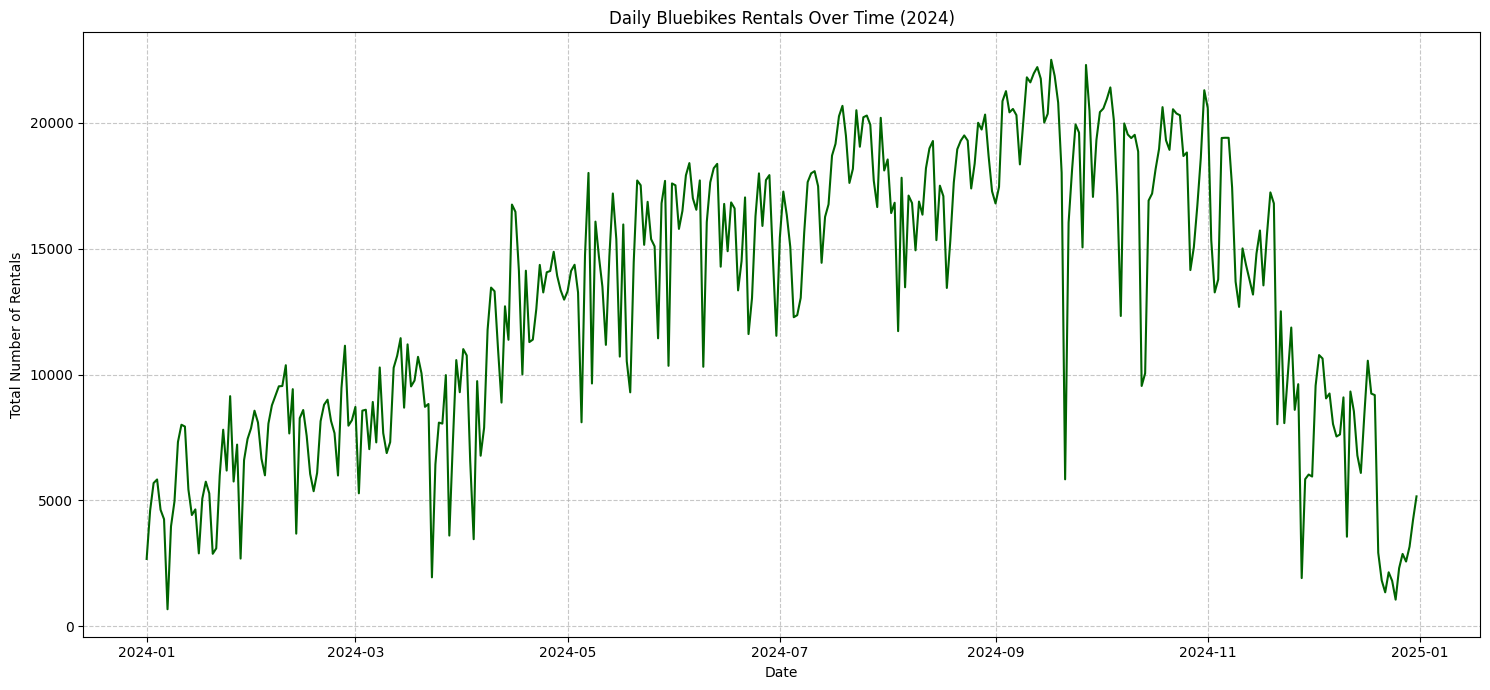

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate hourly rentals to daily rentals
daily_rentals_df = hourly_rentals_df_complete.groupby('date')['rental'].sum().reset_index()

# Convert 'date' column to datetime objects for plotting
daily_rentals_df['date'] = pd.to_datetime(daily_rentals_df['date'])

plt.figure(figsize=(15, 7))
# Plot all daily rentals
sns.lineplot(x='date', y='rental', data=daily_rentals_df, color='darkgreen')

plt.title('Daily Bluebikes Rentals Over Time (2024)')
plt.xlabel('Date')
plt.ylabel('Total Number of Rentals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'daily_rental_{YEAR}.pdf')
plt.savefig(f'daily_rental_{YEAR}.eps')
plt.show()

In [13]:
import pandas as pd

# Ensure df_imputed (weather data) index is a datetime index and UTC localized
# It should already be from previous steps, so we only need to ensure it's a DatetimeIndex.
# The tz_localize call was redundant and caused the error, as it's already tz-aware.
# Removed: df_imputed.index = pd.to_datetime(df_imputed.index).tz_localize('UTC')
# Ensure the index is a DatetimeIndex, but do not re-localize if already tz-aware
if not isinstance(df_imputed.index, pd.DatetimeIndex):
    df_imputed.index = pd.to_datetime(df_imputed.index)
if df_imputed.index.tz is None:
    df_imputed.index = df_imputed.index.tz_localize('UTC')

df_hourly = hourly_rentals_df_complete

# Prepare hourly_rentals_df for merging
# Convert 'date' column to datetime and combine with 'hour' to create a full datetime column
df_hourly['datetime'] = pd.to_datetime(df_hourly['date'].astype(str) + ' ' + df_hourly['hour'].astype(str) + ':00:00')
# Set 'datetime' as index and localize to UTC to match df_imputed
df_hourly = df_hourly.set_index('datetime').tz_localize('UTC')

# Perform a left merge to keep all hourly weather data and add rental data where available
# The index of df_imputed (weather data) will be preserved.
# Include 'date', 'month', 'weekday', and 'hour' from hourly_rentals_df in the merge
combined_df = df_imputed.merge(df_hourly[['rental', 'date', 'month', 'weekday', 'hour']], left_index=True, right_index=True, how='left')

# Fill any remaining NaN rental values with 0 for all non-November months
# Since November data is now included, this will fill NaNs for any missing rental hours across the entire year.
combined_df['rental'] = combined_df['rental'].fillna(0)

combined_df['temp'] = round(combined_df['Air_Temp_F'])

# Display the first few and last few rows of the combined DataFrame
#print("Preview of combined DataFrame (first 10 rows):")
#display(combined_df.head(10))
#print("Preview of combined DataFrame (last 10 rows):")
#display(combined_df.tail(10))

df = combined_df.copy() # Explicitly create a copy to avoid SettingWithCopyWarning
# Assign dew point temperature to 'wb_temp' as requested
df['wb_temp'] = df['Dew_Point_Temp_F']

df['rel_humidity'] = df['Relative_Humidity_Pct']

df['precip_in'] = df['Precipitation_Inches']

df['wind_speed'] = df['Wind_Speed_Knots'] # Map wind speed

# Convert 'date' column to datetime type
df['date'] = pd.to_datetime(df['date'])

# Add 'month' column
df['month'] = df['date'].dt.month

# Add 'day' of the month column
df['day'] = df['date'].dt.day

# Reorder columns as requested
# First, identify the desired leading columns
leading_columns = ['rental', 'month', 'day', 'date', 'weekday', 'hour', 'temp', 'rel_humidity', 'wb_temp', 'precip_in', 'wind_speed']

# Then get all other columns that are not in the leading_columns
other_columns = [col for col in df.columns if col not in leading_columns]

# Combine them to create the new column order
new_column_order = leading_columns + other_columns

# Reindex the DataFrame with the new column order
df = df[new_column_order]

# Drop original weather data columns that have been renamed or are no longer needed
df.drop(columns=['date', 'Air_Temp_F', 'Relative_Humidity_Pct', 'Precipitation_Inches', 'Dew_Point_Temp_F', 'Wind_Speed_Knots'], inplace=True)

# Save the combined DataFrame to a new CSV file
combined_output_filename = f"combined_rentals_weather_wind_{YEAR}.csv"
df.to_csv(combined_output_filename)

print(f"\nCombined rental and weather data saved to '{combined_output_filename}'")


Combined rental and weather data saved to 'combined_rentals_weather_wind_2024.csv'


In [14]:
display(df)

,rental,month,day,weekday,hour,temp,rel_humidity,wb_temp,precip_in,wind_speed
2024-01-01 00:00:00+00:00,185.0,1,1,1,0,34.0,62.475,23.0,0.0,9.0
2024-01-01 01:00:00+00:00,208.0,1,1,1,1,33.0,63.590,22.0,0.0,7.0
2024-01-01 02:00:00+00:00,92.0,1,1,1,2,33.0,66.320,23.0,0.0,7.0
2024-01-01 03:00:00+00:00,32.0,1,1,1,3,33.0,66.320,23.0,0.0,5.0
2024-01-01 04:00:00+00:00,6.0,1,1,1,4,33.0,66.320,23.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00+00:00,237.0,12,31,2,19,49.0,58.300,35.0,0.0,5.0
2024-12-31 20:00:00+00:00,207.0,12,31,2,20,44.0,67.660,34.0,0.0,9.0
2024-12-31 21:00:00+00:00,175.0,12,31,2,21,42.0,79.110,36.0,0.0,4.0
2024-12-31 22:00:00+00:00,160.0,12,31,2,22,41.0,82.220,36.0,0.0,4.0


In [15]:
with open('combined.tex', 'w') as f:
    f.write(df.to_latex())

[185. 208.  92.  32.   6.  14.  25.  30.  49. 105.  94. 139. 183. 187.
 251. 285. 214. 175. 126.  86.  76.  67.  28.  20.  17.  12.   7.   4.
   5.  38. 104. 252. 462. 262. 163. 184. 214. 226. 249. 339. 493. 583.
 420. 236. 152.  95.  40.  40.  14.   9.   7.   3.   8.  53. 128. 352.
 645. 368. 222. 214. 254. 235. 272. 373. 616. 764. 477. 279. 185. 108.
  70.  34.  18.  10.   7.   6.  10.  49. 138. 358. 678. 387. 225. 260.
 304. 277. 324. 374. 557. 708. 470. 292. 172. 110.  61.  37.  15.   8.
   6.]
540.9596994535519
SST: 2214094429.73


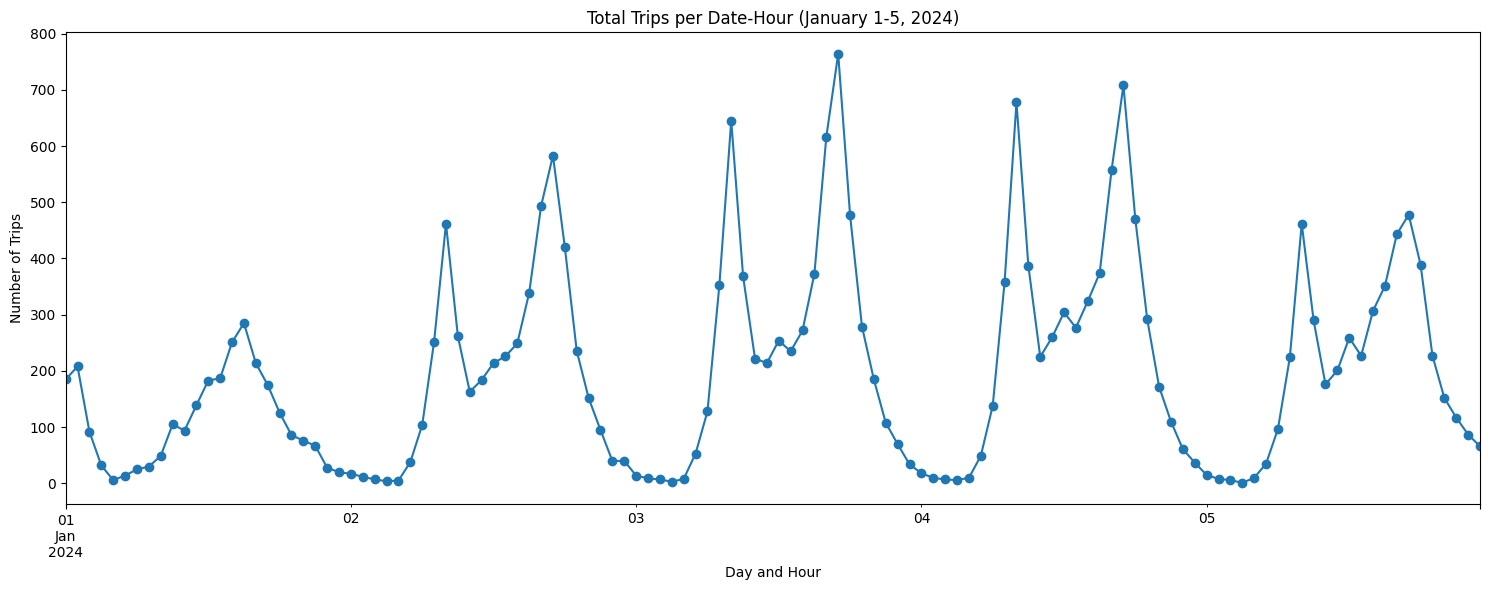

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

rentals = combined_df['rental']
rentalvalues = rentals.values
print(rentalvalues[0:99])
print(rentalvalues.mean())

diff = rentalvalues - rentalvalues.mean()
diff2 = diff ** 2
SST = diff2.sum()
print(f"SST: {SST:.2f}")

# Convert the index to datetime objects for easy filtering
rentals.index = pd.to_datetime(rentals.index)

# Filter for the first five days of the current YEAR
first_three_days_trips = rentals.loc[f'{YEAR}-01-01':f'{YEAR}-01-05']

plt.figure(figsize=(15, 6))
first_three_days_trips.plot(kind='line', marker='o', linestyle='-')
plt.title(f'Total Trips per Date-Hour (January 1-5, {YEAR})')
plt.xlabel('Day and Hour')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.savefig(f'rentals_hourly_{YEAR}.pdf')
plt.savefig(f'rentals_hourly_{YEAR}.eps')
plt.show()